# 우리금융 실습 답안

강의(`우리금융 실습 part 1.ipynb`)에서 배운 코드로 작성한 답안입니다.

## 0. 패키지 불러오기

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.datasets import load_breast_cancer

from scipy.stats import chi2

warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False

---
# 실습 1. 이상치 제거 전후 비교

세 데이터에 선형회귀를 맞춘 다음, **이상치를 빼기 전/후**를 비교합니다.

- 비교 1: 잔차가 정규분포처럼 보이는지 → **QQ plot**
- 비교 2: 변수가 유의한지 → **개별 t검정**, **전체 F검정**

범주형 변수는 빼고, 숫자 변수만 사용합니다.

| 데이터 | Y (맞추려는 값) | 사용하는 X |
|---|---|---|
| tips | tip | total_bill, size |
| mpg | mpg | cylinders, displacement, horsepower, weight, acceleration, model_year |
| longley | TOTEMP | GNPDEFL, GNP, UNEMP, ARMED, POP, YEAR |

## 이상치는 어떻게 고르나?

회귀에서는 **한 점이 결과를 너무 흔들면** 이상치(영향점)로 봅니다.

강의에서 배운 `model.get_influence().summary_frame()` 안의 **Cook's distance (`cooks_d`)** 를 사용합니다.

- `cooks_d`가 크다 = 그 점을 빼면 회귀선이 많이 바뀐다.
- 자주 쓰는 기준: **`cooks_d > 4/n`** (`n`은 데이터 개수)
- 이 기준보다 큰 점을 이상치로 보고 제거합니다.

## 1-1. 데이터 불러오기

In [16]:
tips = sns.load_dataset('tips')
mpg = sns.load_dataset('mpg')
longley = sm.datasets.longley.load_pandas().data

print('tips')
print(tips.head())
print(tips.dtypes)

print('\nmpg')
print(mpg.head())
print(mpg.dtypes)
print('결측치 개수')
print(mpg.isnull().sum())

print('\nlongley')
print(longley.head())
print(longley.dtypes)

tips
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

mpg
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa

`mpg`의 `horsepower`에는 빈 값이 있어서, 회귀에 넣기 전에 그 행을 지웁니다.  
`origin`과 `name`은 범주형/이름이라 실습 1에서는 사용하지 않습니다.

## 1-2. 세 데이터에 같이 쓸 함수

한 데이터마다 하는 일:

1. 숫자 변수만으로 회귀 적합
2. Cook's D가 `4/n`보다 큰 점을 이상치로 표시하고 제거
3. 제거 전/후 QQ plot 그리기
4. 제거 전/후 개별 t검정, 전체 F검정 비교

In [17]:
# 모델 적합 함수
def fit_ols(X, y):
    Xc = sm.add_constant(X, has_constant='add')
    model = sm.OLS(y, Xc).fit()
    return model

# 이상치로 분류되는 점을 찾아 해당 인덱스에 mask를 출력하는 함수
def find_outliers_cooks(model):
    """cooks_d > 4/n 인 점을 이상치로 본다."""
    sf = model.get_influence().summary_frame()
    n = int(model.nobs)
    cutoff = 4 / n
    mask = sf['cooks_d'] > cutoff

    print(f'데이터 개수 n = {n}')
    print(f'이상치 기준: cooks_d > 4/n = {cutoff:.4f}')
    print(f'이상치 개수: {mask.sum()}개')
    print('\n이상치로 분류된 점 (cooks_d)')
    print(sf.loc[mask, ['cooks_d']] if mask.any() else '(없음)')
    return mask


# QQ plot을 그리는 함수
def plot_qq(model, title):
    """Residual QQ plot"""
    sm.qqplot(model.resid, line='45', fit=True)
    plt.title(title)
    plt.show()


# 모델 유의성을 판단하는 함수
def print_significance(model, label):
    """전체 F검정 + 개별 t검정"""
    print(f'\n[{label}] 유의성 검정')
    print('--- 전체 F검정 ---')
    print(f'F 통계량 = {model.fvalue:.4f}')
    print(f'p-value  = {model.f_pvalue:.4g}')
    if model.f_pvalue < 0.05:
        print('해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.')
    else:
        print('해석: p-value가 0.05보다 작지 않으므로, 모형 전체가 유의하다고 보기 어렵다.')

    print('\n--- 개별 t검정 ---')
    tbl = pd.DataFrame({
        '계수': model.params,
        't값': model.tvalues,
        'p-value': model.pvalues
    })
    tbl['유의? (0.05)'] = np.where(tbl['p-value'] < 0.05, '유의', '유의하지 않음')
    print(tbl.round(4))
    return tbl

# 이상치 제거 전/후를 비교하는 함수.
def compare_before_after(X, y, name):
    print('=' * 60)
    print(name)
    print('=' * 60)

    # 이상치 제거 전
    model_before = fit_ols(X, y)
    print('\n[이상치 제거 전] 회귀 결과')
    print(model_before.summary())

    mask = find_outliers_cooks(model_before)
    plot_qq(model_before, f'{name} - QQ plot (before)')
    sig_before = print_significance(model_before, '이상치 제거 전')

    # 이상치 제거 후
    keep = ~mask.reindex(X.index).fillna(False).astype(bool)
    n_removed = int((~keep).sum())

    if n_removed == 0:
        print('\n제거할 이상치가 없습니다. 제거 후 결과는 제거 전과 같습니다.')
        model_after = model_before
        sig_after = sig_before
    else:
        print(f'\ncooks_d 기준으로 {n_removed}개 점을 제거하고 다시 적합합니다.')
        model_after = fit_ols(X.loc[keep], y.loc[keep])
        print('\n[이상치 제거 후] 회귀 결과')
        print(model_after.summary())
        plot_qq(model_after, f'{name} - QQ plot (after)')
        sig_after = print_significance(model_after, '이상치 제거 후')

    print('\n[계수별 p-value 비교]')
    common = sig_before.index.intersection(sig_after.index)
    cmp = pd.DataFrame({
        'p_제거전': sig_before.loc[common, 'p-value'],
        'p_제거후': sig_after.loc[common, 'p-value'],
        '제거전': sig_before.loc[common, '유의? (0.05)'],
        '제거후': sig_after.loc[common, '유의? (0.05)']
    })
    print(cmp.round(4))
    print('\n전체 F검정 p-value: 제거 전 =', f'{model_before.f_pvalue:.4g}',
          '/ 제거 후 =', f'{model_after.f_pvalue:.4g}')

## 1-3. tips (Y = tip)

범주형 `sex`, `smoker`, `day`, `time`은 제외합니다.

tips (Y = tip)

[이상치 제거 전] 회귀 결과
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           9.67e-34
Time:                        02:40:29   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.66

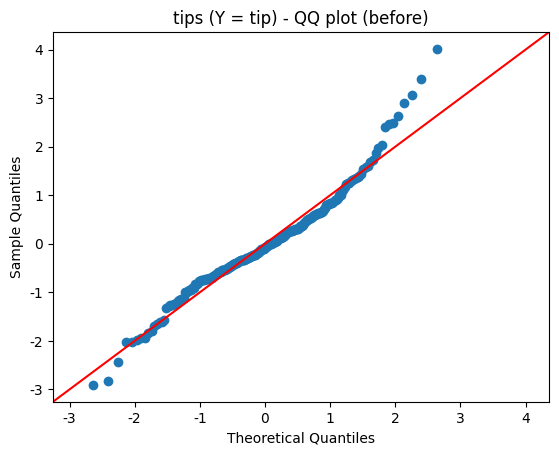


[이상치 제거 전] 유의성 검정
--- 전체 F검정 ---
F 통계량 = 105.9481
p-value  = 9.665e-34
해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.

--- 개별 t검정 ---
                계수       t값  p-value 유의? (0.05)
const       0.6689   3.4551   0.0006         유의
total_bill  0.0927  10.1719   0.0000         유의
size        0.1926   2.2575   0.0249         유의

cooks_d 기준으로 20개 점을 제거하고 다시 적합합니다.

[이상치 제거 후] 회귀 결과
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     136.5
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           2.45e-39
Time:                        02:40:29   Log-Likelihood:                -252.88
No. Observations:                 224   AIC:                             511.8
Df Residuals:                     221   BIC:                             5

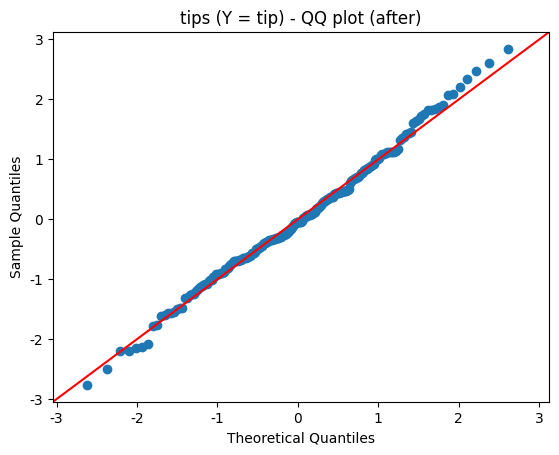


[이상치 제거 후] 유의성 검정
--- 전체 F검정 ---
F 통계량 = 136.5479
p-value  = 2.45e-39
해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.

--- 개별 t검정 ---
                계수       t값  p-value 유의? (0.05)
const       0.6396   3.9726   0.0001         유의
total_bill  0.1008  12.0440   0.0000         유의
size        0.1331   1.8086   0.0719    유의하지 않음

[계수별 p-value 비교]
             p_제거전   p_제거후 제거전      제거후
const       0.0006  0.0001  유의       유의
total_bill  0.0000  0.0000  유의       유의
size        0.0249  0.0719  유의  유의하지 않음

전체 F검정 p-value: 제거 전 = 9.665e-34 / 제거 후 = 2.45e-39


In [18]:
tips_num = tips[['total_bill', 'size', 'tip']].dropna().copy()
X_tips = tips_num[['total_bill', 'size']].astype(float)
y_tips = tips_num['tip'].astype(float)

compare_before_after(X_tips, y_tips, 'tips (Y = tip)')

### tips 해석

- **이상치**: Cook's D가 `4/n`보다 큰 점 **20개**를 제거했다. 이 점들은 회귀선에 미치는 영향이 커서 이상치로 판단했다.
- **QQ plot**: 제거 전에는 값이 클 때 점들이 빨간 직선에서 많이 벗어나 보였다. 20개를 빼고 다시 적합하면 점들이 거의 빨간 선 근처에 있다. 큰 쪽 꼬리의 이상 잔차가 줄어든 것이다.
- **유의성**: 개별 t검정과 전체 F검정의 p-value를 제거 전후로 비교하면 된다.

## 1-4. mpg (Y = mpg)

범주형 `origin`, 차 이름 `name`은 제외합니다. `horsepower` 빈 값은 삭제합니다.

mpg (Y = mpg)

[이상치 제거 전] 회귀 결과
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     272.2
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          3.79e-135
Time:                        02:40:30   Log-Likelihood:                -1036.5
No. Observations:                 392   AIC:                             2087.
Df Residuals:                     385   BIC:                             2115.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -

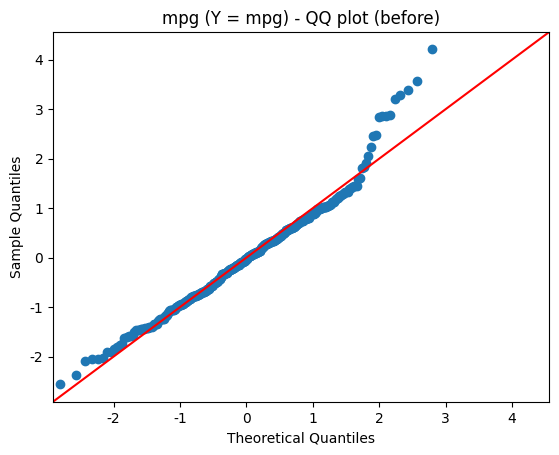


[이상치 제거 전] 유의성 검정
--- 전체 F검정 ---
F 통계량 = 272.2341
p-value  = 3.792e-135
해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.

--- 개별 t검정 ---
                   계수       t값  p-value 유의? (0.05)
const        -14.5353  -3.0511   0.0024         유의
cylinders     -0.3299  -0.9932   0.3212    유의하지 않음
displacement   0.0077   1.0436   0.2973    유의하지 않음
horsepower    -0.0004  -0.0283   0.9775    유의하지 않음
weight        -0.0068 -10.1409   0.0000         유의
acceleration   0.0853   0.8357   0.4038    유의하지 않음
model_year     0.7534  14.3176   0.0000         유의

cooks_d 기준으로 27개 점을 제거하고 다시 적합합니다.

[이상치 제거 후] 회귀 결과
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     371.2
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          2.47e-150
Time:          

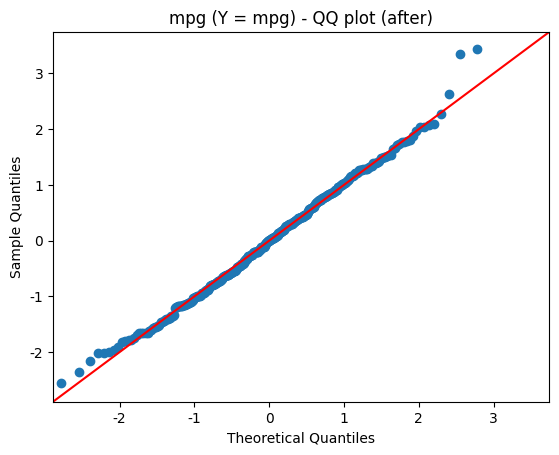


[이상치 제거 후] 유의성 검정
--- 전체 F검정 ---
F 통계량 = 371.1988
p-value  = 2.466e-150
해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.

--- 개별 t검정 ---
                  계수       t값  p-value 유의? (0.05)
const        -8.5006  -2.1422   0.0328         유의
cylinders    -0.3306  -1.1713   0.2422    유의하지 않음
displacement  0.0014   0.2115   0.8326    유의하지 않음
horsepower   -0.0059  -0.4854   0.6277    유의하지 않음
weight       -0.0061  -9.5945   0.0000         유의
acceleration -0.1094  -1.2197   0.2234    유의하지 않음
model_year    0.7057  16.2383   0.0000         유의

[계수별 p-value 비교]
               p_제거전   p_제거후      제거전      제거후
const         0.0024  0.0328       유의       유의
cylinders     0.3212  0.2422  유의하지 않음  유의하지 않음
displacement  0.2973  0.8326  유의하지 않음  유의하지 않음
horsepower    0.9775  0.6277  유의하지 않음  유의하지 않음
weight        0.0000  0.0000       유의       유의
acceleration  0.4038  0.2234  유의하지 않음  유의하지 않음
model_year    0.0000  0.0000       유의       유의

전체 F검정 p-value: 제거 전 = 3.792e-135 / 제거 후 = 2.466e-150


In [19]:
mpg_num = mpg[['cylinders', 'displacement', 'horsepower', 'weight',
               'acceleration', 'model_year', 'mpg']].dropna().copy()
X_mpg = mpg_num.drop(columns='mpg').astype(float)
y_mpg = mpg_num['mpg'].astype(float)

compare_before_after(X_mpg, y_mpg, 'mpg (Y = mpg)')

### mpg 해석

- **이상치**: Cook's D가 `4/n`보다 큰 점 **27개**를 제거했다.
- **QQ plot**: tips와 거의 같은 양상이다. 제거 전에는 값이 클 때 빨간 직선에서 벗어나는 점이 많았고, 제거 후 다시 적합하면 점들이 빨간 선 근처에 모인다.
- **유의성**: 개별 t검정과 전체 F검정의 p-value를 제거 전후로 비교하면 된다.

## 1-5. longley (Y = TOTEMP)

모두 숫자 변수입니다. 데이터가 16개뿐이라 이상치 하나에도 결과가 잘 흔들립니다.

longley (Y = TOTEMP)

[이상치 제거 전] 회귀 결과
                            OLS Regression Results                            
Dep. Variable:                 TOTEMP   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                     330.3
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           4.98e-10
Time:                        02:40:30   Log-Likelihood:                -109.62
No. Observations:                  16   AIC:                             233.2
Df Residuals:                       9   BIC:                             238.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3

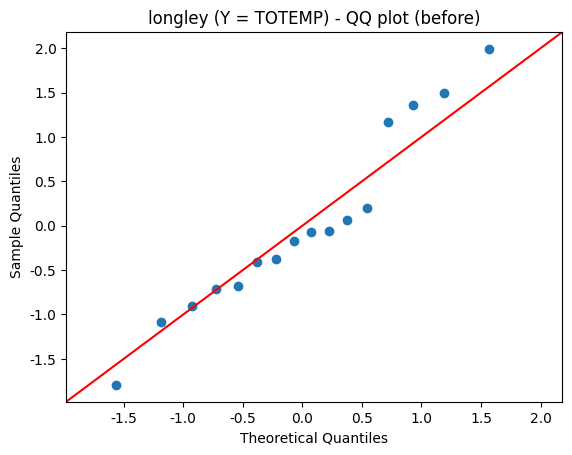


[이상치 제거 전] 유의성 검정
--- 전체 F검정 ---
F 통계량 = 330.2853
p-value  = 4.984e-10
해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.

--- 개별 t검정 ---
                   계수      t값  p-value 유의? (0.05)
const   -3.482259e+06 -3.9108   0.0036         유의
GNPDEFL  1.506190e+01  0.1774   0.8631    유의하지 않음
GNP     -3.580000e-02 -1.0695   0.3127    유의하지 않음
UNEMP   -2.020200e+00 -4.1364   0.0025         유의
ARMED   -1.033200e+00 -4.8220   0.0009         유의
POP     -5.110000e-02 -0.2261   0.8262    유의하지 않음
YEAR     1.829151e+03  4.0159   0.0030         유의

cooks_d 기준으로 2개 점을 제거하고 다시 적합합니다.

[이상치 제거 후] 회귀 결과
                            OLS Regression Results                            
Dep. Variable:                 TOTEMP   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     385.4
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.86e-08
Time:                    

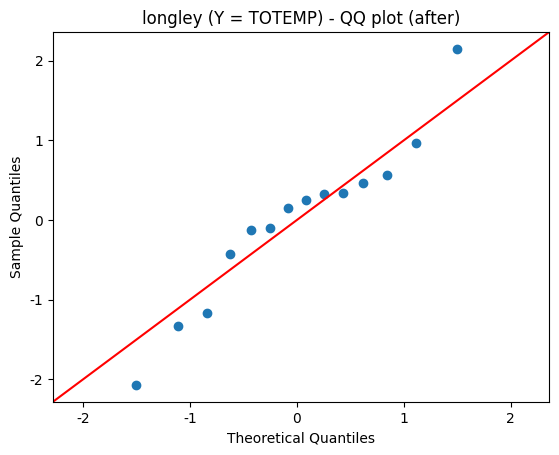


[이상치 제거 후] 유의성 검정
--- 전체 F검정 ---
F 통계량 = 385.4108
p-value  = 1.86e-08
해석: p-value가 0.05보다 작으므로, 모형 전체가 유의하다.

--- 개별 t검정 ---
                   계수      t값  p-value 유의? (0.05)
const   -4.484790e+06 -3.9998   0.0052         유의
GNPDEFL -2.920500e+00 -0.0384   0.9705    유의하지 않음
GNP     -7.460000e-02 -1.9638   0.0903    유의하지 않음
UNEMP   -2.618300e+00 -4.8364   0.0019         유의
ARMED   -1.179100e+00 -5.3481   0.0011         유의
POP      2.600000e-01  1.1275   0.2967    유의하지 않음
YEAR     2.333192e+03  4.0656   0.0048         유의

[계수별 p-value 비교]
          p_제거전   p_제거후      제거전      제거후
const    0.0036  0.0052       유의       유의
GNPDEFL  0.8631  0.9705  유의하지 않음  유의하지 않음
GNP      0.3127  0.0903  유의하지 않음  유의하지 않음
UNEMP    0.0025  0.0019       유의       유의
ARMED    0.0009  0.0011       유의       유의
POP      0.8262  0.2967  유의하지 않음  유의하지 않음
YEAR     0.0030  0.0048       유의       유의

전체 F검정 p-value: 제거 전 = 4.984e-10 / 제거 후 = 1.86e-08


In [20]:
X_long = longley.drop(columns='TOTEMP').astype(float)
y_long = longley['TOTEMP'].astype(float)

compare_before_after(X_long, y_long, 'longley (Y = TOTEMP)')

### longley 해석

- **이상치**: Cook's D가 `4/n`보다 큰 점 **2개**를 제거했다.
- **QQ plot**: 제거 전과 거의 같은 양상이다. 점이 2개뿐이라 QQ plot 모양의 변화는 거의 없다.
- **유의성**: 개별 t검정과 전체 F검정의 p-value를 제거 전후로 비교하면 된다.

---
# 실습 2. 전진선택법으로 변수 고르기

실습 1과 같은 세 데이터를 씁니다.

- 변수 선택: 강의에서 배운 **전진선택법 (AIC가 더 줄어들지 않을 때까지 변수를 하나씩 추가)**
- 범주형 변수는 **`pd.get_dummies()`** 로 0/1 숫자로 바꿉니다. (과제문의 `pd.dummies()`는 이 함수입니다.)
- 고른 변수로 Y를 예측하고 성능을 봅니다.

세 데이터의 Y는 모두 **숫자(연속형)** 입니다.  
`accuracy`(정확도)는 0/1 분류에서 쓰는 지표라서, 여기서는 회귀용 지표를 사용합니다.

- **RMSE**: 예측이 실제와 얼마나 떨어져 있는지 (작을수록 좋음)
- **MAE**: 오차 절대값의 평균 (작을수록 좋음)
- **R2**: 모형이 Y를 얼마나 설명하는지 (1에 가까울수록 좋음)

## 2-1. 전진선택 함수 (강의와 같은 방식)

In [21]:
def forward_selection_simple(data, target, max_features=None):
    """AIC 기준 전진선택법"""
    selected = []
    remaining = list(data.columns)
    current_score = np.inf

    while remaining and (max_features is None or len(selected) < max_features):
        scores = []
        for feature in remaining:
            features = selected + [feature]
            X = sm.add_constant(data[features], has_constant='add')
            model = sm.OLS(target, X).fit()
            scores.append((model.aic, feature))
        scores.sort()  # AIC가 작은 것이 더 좋음
        best_score, best_feature = scores[0]

        if best_score < current_score:
            selected.append(best_feature)
            remaining.remove(best_feature)
            current_score = best_score
            print(f'  + {best_feature}   AIC = {best_score:.3f}')
        else:
            print('  AIC가 더 줄어들지 않아서 멈춤')
            break

    return selected, current_score


def print_perf(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label:12s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return rmse, mae, r2


def run_forward(X, y, name):
    print('\n' + '=' * 60)
    print(name)
    print('=' * 60)
    print('변수:', list(X.columns))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    print('학습 데이터:', X_train.shape, ' / 시험 데이터:', X_test.shape)

    print('\n[전진선택 과정]')
    selected, aic_sel = forward_selection_simple(X_train, y_train)
    print('선택된 변수:', selected)
    print('최종 AIC:', aic_sel)

    # 선택한 변수로 회귀 적합 후 예측
    Xtr = sm.add_constant(X_train[selected], has_constant='add')
    Xte = sm.add_constant(X_test[selected], has_constant='add')
    model = sm.OLS(y_train, Xtr).fit()
    print('\n[전진선택 모형]')
    print(model.summary())

    print('\n[성능]')
    print_perf(y_train, model.predict(Xtr), '학습')
    print_perf(y_test, model.predict(Xte), '시험')

## 2-2. tips (범주형도 원핫인코딩)

In [22]:
tips2 = sns.load_dataset('tips').copy()
y_tips2 = tips2['tip'].astype(float)
X_tips2 = tips2.drop(columns='tip')

# 범주형(sex, smoker, day, time)을 0/1로 변환
X_tips2 = pd.get_dummies(X_tips2, drop_first=True).astype(float)
print(X_tips2.head())

run_forward(X_tips2, y_tips2, 'tips (Y = tip)')

   total_bill  size  sex_Female  smoker_No  day_Fri  day_Sat  day_Sun  \
0       16.99   2.0         1.0        1.0      0.0      0.0      1.0   
1       10.34   3.0         0.0        1.0      0.0      0.0      1.0   
2       21.01   3.0         0.0        1.0      0.0      0.0      1.0   
3       23.68   2.0         0.0        1.0      0.0      0.0      1.0   
4       24.59   4.0         1.0        1.0      0.0      0.0      1.0   

   time_Dinner  
0          1.0  
1          1.0  
2          1.0  
3          1.0  
4          1.0  

tips (Y = tip)
변수: ['total_bill', 'size', 'sex_Female', 'smoker_No', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Dinner']
학습 데이터: (170, 8)  / 시험 데이터: (74, 8)

[전진선택 과정]
  + total_bill   AIC = 512.071
  + size   AIC = 505.620
  + smoker_No   AIC = 505.153
  AIC가 더 줄어들지 않아서 멈춤
선택된 변수: ['total_bill', 'size', 'smoker_No']
최종 AIC: 505.15345506334216

[전진선택 모형]
                            OLS Regression Results                            
Dep. Variable:            

`drop_first=True`는 더미 변수가 서로 완전히 겹치지 않게 하는 설정입니다. 강의 로지스틱 부분과 같습니다.  

## 2-3. mpg (`origin`만 원핫인코딩)

`name`은 차 이름이라 거의 행마다 다릅니다. 더미로 만들면 변수가 너무 많아져서 제외합니다.  
`origin`은 국가 코드이므로 범주형으로 보고 원핫인코딩합니다.

In [23]:
mpg2 = sns.load_dataset('mpg').dropna().copy()
y_mpg2 = mpg2['mpg'].astype(float)

X_mpg2 = mpg2.drop(columns=['mpg', 'name'])
X_mpg2['origin'] = X_mpg2['origin'].astype('category')
X_mpg2 = pd.get_dummies(X_mpg2, columns=['origin'], drop_first=True).astype(float)
print(X_mpg2.head())

run_forward(X_mpg2, y_mpg2, 'mpg (Y = mpg)')

   cylinders  displacement  horsepower  weight  acceleration  model_year  \
0        8.0         307.0       130.0  3504.0          12.0        70.0   
1        8.0         350.0       165.0  3693.0          11.5        70.0   
2        8.0         318.0       150.0  3436.0          11.0        70.0   
3        8.0         304.0       150.0  3433.0          12.0        70.0   
4        8.0         302.0       140.0  3449.0          10.5        70.0   

   origin_japan  origin_usa  
0           0.0         1.0  
1           0.0         1.0  
2           0.0         1.0  
3           0.0         1.0  
4           0.0         1.0  

mpg (Y = mpg)
변수: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']
학습 데이터: (274, 8)  / 시험 데이터: (118, 8)

[전진선택 과정]
  + weight   AIC = 1592.806
  + model_year   AIC = 1476.351
  + origin_usa   AIC = 1453.597
  + horsepower   AIC = 1452.806
  + displacement   AIC = 1450.159
  AIC가 더 줄어들지 않아서 멈춤
선택된

## 2-4. longley (범주형 없음)

데이터가 16개뿐이라 시험 셋이 매우 작습니다. 성능 숫자보다는 **어떤 변수가 선택됐는지**를 보면 됩니다.

In [24]:
longley2 = sm.datasets.longley.load_pandas().data.copy()
y_long2 = longley2['TOTEMP'].astype(float)
X_long2 = longley2.drop(columns='TOTEMP').astype(float)
X_long2 = pd.get_dummies(X_long2, drop_first=True).astype(float)  # 범주형은 없어서 그대로

run_forward(X_long2, y_long2, 'longley (Y = TOTEMP)')


longley (Y = TOTEMP)
변수: ['GNPDEFL', 'GNP', 'UNEMP', 'ARMED', 'POP', 'YEAR']
학습 데이터: (11, 6)  / 시험 데이터: (5, 6)

[전진선택 과정]
  + GNP   AIC = 179.107
  + POP   AIC = 171.341
  AIC가 더 줄어들지 않아서 멈춤
선택된 변수: ['GNP', 'POP']
최종 AIC: 171.34070851187192

[전진선택 모형]
                            OLS Regression Results                            
Dep. Variable:                 TOTEMP   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     189.2
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.84e-07
Time:                        02:40:31   Log-Likelihood:                -82.670
No. Observations:                  11   AIC:                             171.3
Df Residuals:                       8   BIC:                             172.5
Df Model:                           2                                         
Covariance Type:            nonrobus

---
# 실습 3. 유방암 데이터 로지스틱 회귀 (두 가지 방식)

강의와 같이 두 가지로 맞춥니다.

1. `sklearn`의 `LogisticRegression` → 예측이 얼마나 맞는지 (정확도 등)
2. `statsmodels` GLM (`family = Binomial`) → 계수 결과 + 적합성(LLR p값)

- **성능**: 혼동행렬, 정확도(accuracy), 분류 보고서
- **적합성**: **LLR p값**만 사용 (0.05보다 작으면 모형이 의미 있게 적합된 것으로 봄)

## 3-1. 데이터 확인

In [25]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print('타깃 이름:', data.target_names)  # 0: 악성, 1: 양성
print(df.head())
print('\n클래스 개수')
print(df['target'].value_counts())

타깃 이름: ['malignant' 'benign']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter

In [26]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 강의와 같이 표준화 (변수 단위를 맞춤)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_s = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_s = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('학습:', X_train.shape, ' / 시험:', X_test.shape)

학습: (398, 30)  / 시험: (171, 30)


## 3-2. 방식 1. sklearn LogisticRegression

예측(분류)에 초점을 둔 방법입니다. 강의와 같이 `solver='liblinear'`를 사용합니다.

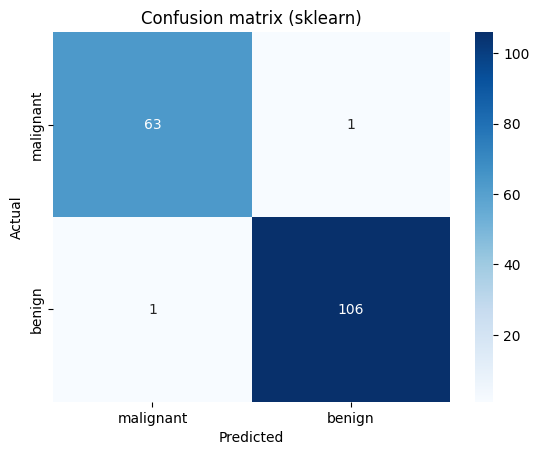


[sklearn] 정확도: 0.9883040935672515

[sklearn] 분류 보고서
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



In [27]:
logreg = LogisticRegression(solver='liblinear', random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix (sklearn)')
plt.show()

print('\n[sklearn] 정확도:', accuracy_score(y_test, y_pred))
print('\n[sklearn] 분류 보고서')
print(classification_report(y_test, y_pred, target_names=data.target_names))

- **정확도**: 전체 중에서 클래스를 맞춘 비율입니다.
- **혼동행렬**: 실제와 예측이 어떻게 갈렸는지 보여 줍니다.
- sklearn은 예측은 잘 되지만, LLR p값 같은 적합성 숫자는 주지 않습니다. 적합성은 방식 2에서 봅니다.

## 3-3. 방식 2. statsmodels GLM (Binomial)

강의와 같이 `family=sm.families.Binomial()` 을 사용합니다.  
변수 이름에 띄어쓰기가 있어서 `Q('mean radius')`처럼 감쌉니다.

## 3-4. 방식 2의 예측 성능

In [28]:
train_df = X_train_s.copy()
train_df['target'] = y_train.values

safe = []
for col in X.columns:
    if not str(col).isidentifier():
        safe.append(f"Q('{col}')")
    else:
        safe.append(col)

formula = 'target ~ ' + ' + '.join(safe)
print('formula 앞부분:', formula[:200], '...')

glm_model = smf.glm(formula=formula, data=train_df, family=sm.families.Binomial()).fit()
print(glm_model.summary())

formula 앞부분: target ~ Q('mean radius') + Q('mean texture') + Q('mean perimeter') + Q('mean area') + Q('mean smoothness') + Q('mean compactness') + Q('mean concavity') + Q('mean concave points') + Q('mean symmetry' ...
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                  398
Model:                            GLM   Df Residuals:                      367
Model Family:                Binomial   Df Model:                           30
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Tue, 25 Aug 2026   Deviance:                   2.3216e-09
Time:                        02:40:31   Pearson chi2:                 1.16e-09
No. Iterations:                    29   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                  

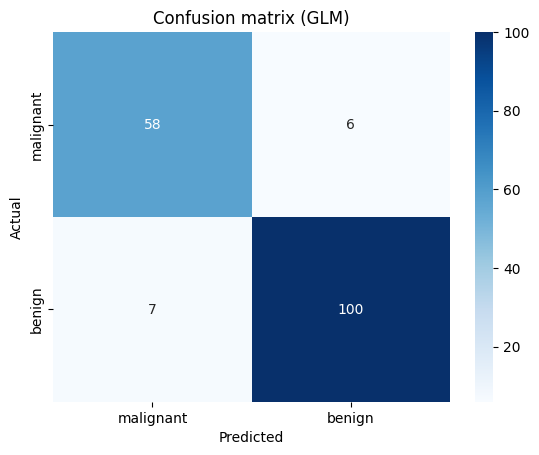


[GLM] 정확도: 0.9239766081871345

[GLM] 분류 보고서
              precision    recall  f1-score   support

   malignant       0.89      0.91      0.90        64
      benign       0.94      0.93      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



In [29]:
y_prob = glm_model.predict(X_test_s)
y_pred_glm = (y_prob >= 0.5).astype(int)

cm_glm = confusion_matrix(y_test, y_pred_glm)
sns.heatmap(cm_glm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix (GLM)')
plt.show()

print('\n[GLM] 정확도:', accuracy_score(y_test, y_pred_glm))
print('\n[GLM] 분류 보고서')
print(classification_report(y_test, y_pred_glm, target_names=data.target_names))

## 3-5. 모형 적합성: LLR p값

GLM 요약에는 LLR p값이 바로 안 나올 수 있어서, 변수 없는 모형과 비교해 직접 계산한다.

- 의미: “설명변수가 하나도 필요 없다”는 가정이 맞는지 본다.
- **p값이 0.05보다 작으면** → 그 가정은 기각, 즉 **모형이 적합하다고 볼 수 있다.**
- **p값이 0.05보다 작지 않으면** → 변수들이 Y를 잘 설명한다고 보기 어렵다.

In [30]:
null_model = smf.glm('target ~ 1', data=train_df, family=sm.families.Binomial()).fit()
llr = 2 * (glm_model.llf - null_model.llf)
llr_pvalue = chi2.sf(llr, glm_model.df_model)

print('LLR p-value:', llr_pvalue)

if llr_pvalue < 0.05:
    print('해석: LLR p값이 0.05보다 작으므로 모형이 적합하다.')
else:
    print('해석: LLR p값이 0.05보다 작지 않으므로 모형이 적합하다고 보기 어렵다.')

LLR p-value: nan
해석: LLR p값이 0.05보다 작지 않으므로 모형이 적합하다고 보기 어렵다.
